In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from scipy.stats import skew
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [4]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [5]:
# Define your features and target variable
X = df.drop('medv', axis=1)  # Features
y = df['medv']  # Target variable

In [6]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Apply Yeo-Johnson transform

pt1 = PowerTransformer()

X_train_transformed2 = pt1.fit_transform(X_train)
X_test_transformed2 = pt1.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_transformed2,y_train)

y_pred3 = lr.predict(X_test_transformed2)

print(r2_score(y_test,y_pred3))

pd.DataFrame({'cols':X_train.columns,'Yeo_Johnson_lambdas':pt1.lambdas_})

0.7314914125957745


,cols,Yeo_Johnson_lambdas
0,crim,-0.958995
1,zn,-0.867045
2,indus,0.332416
3,chas,-20.097985
4,nox,-4.033137
5,rm,-0.014434
6,age,1.388267
7,dis,-0.459648
8,rad,-0.367935
9,tax,-0.530211


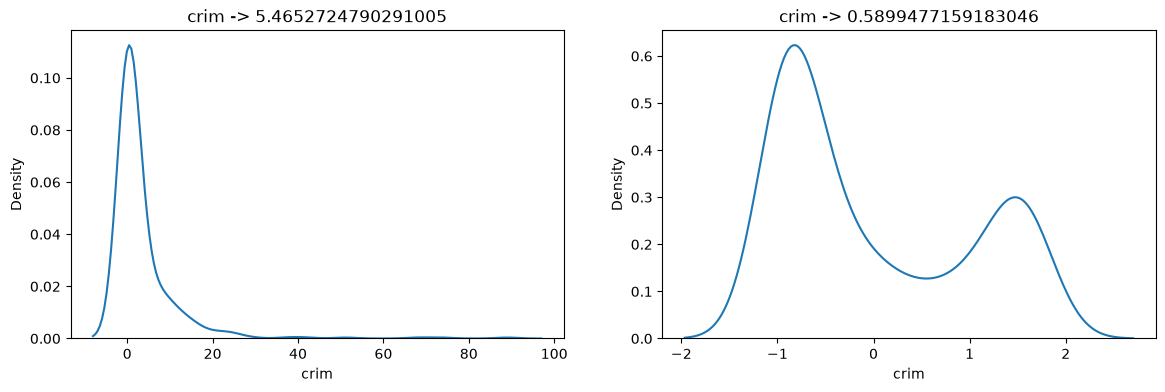

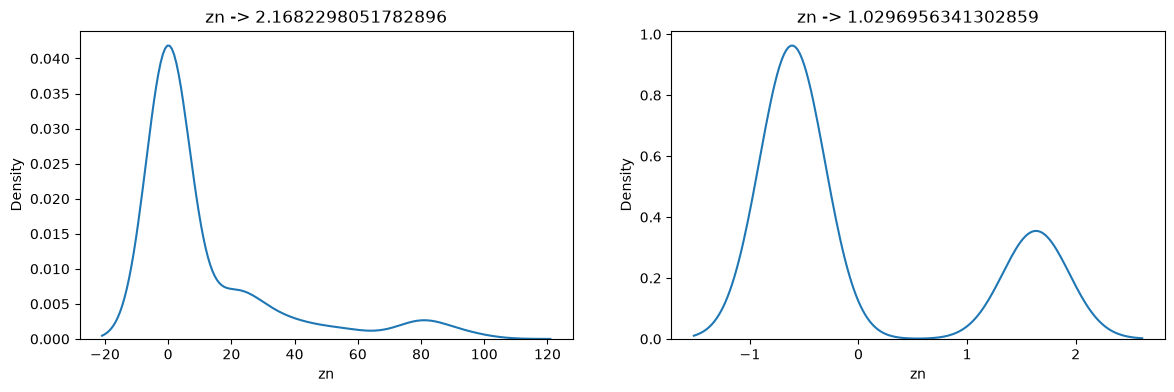

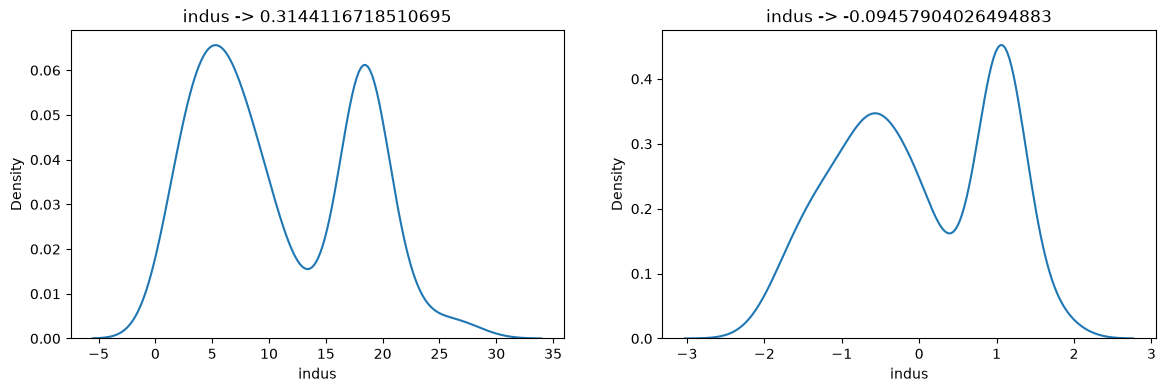

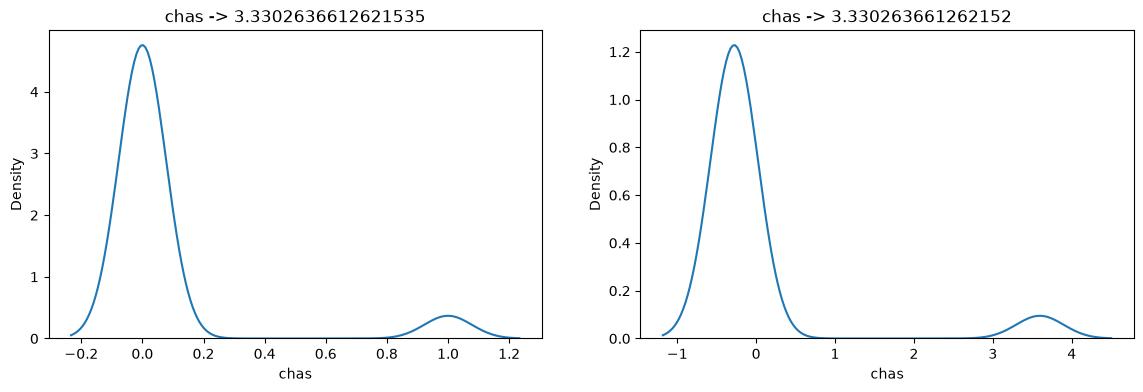

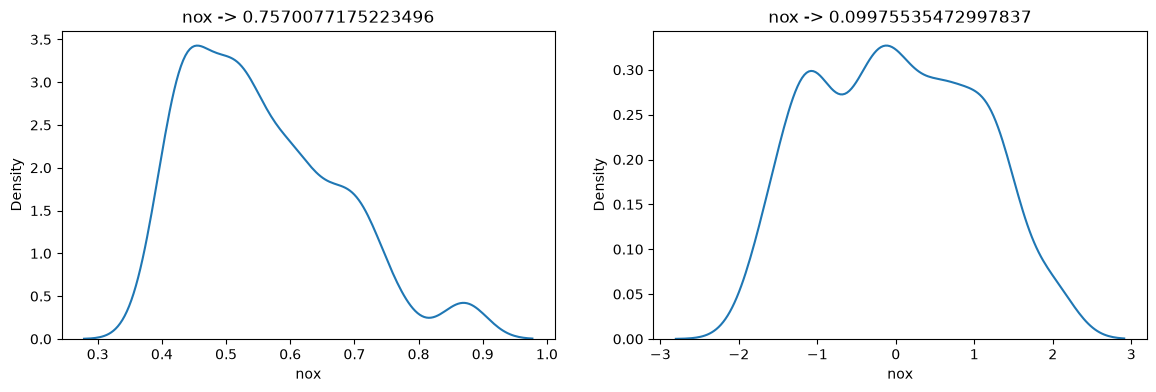

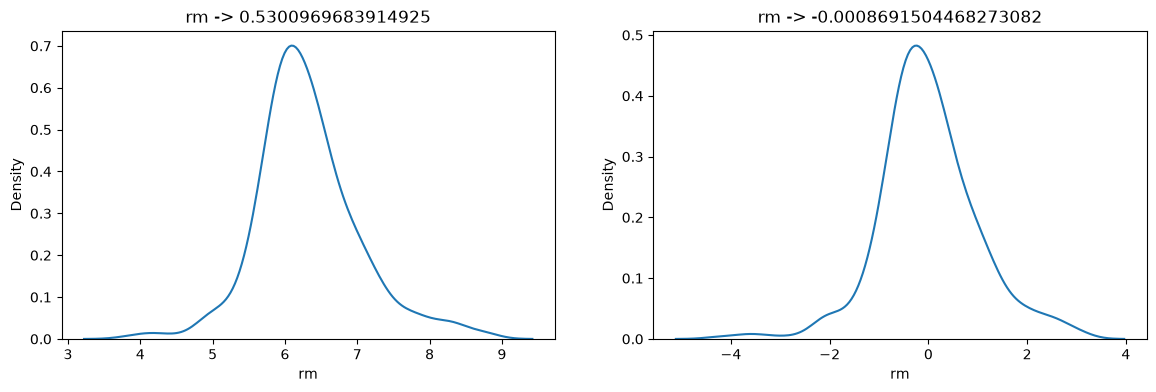

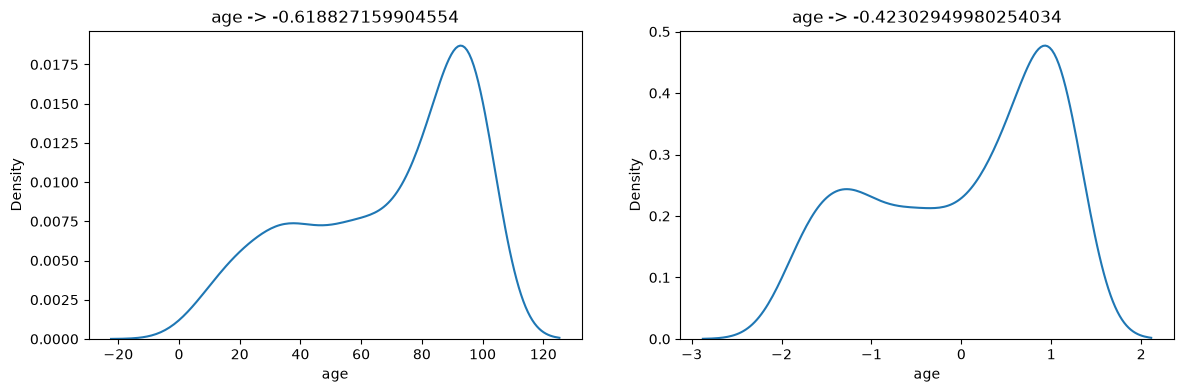

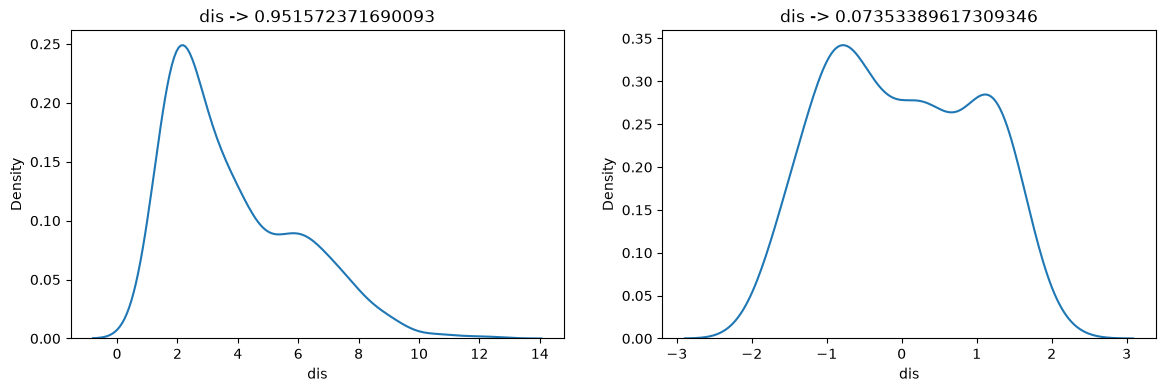

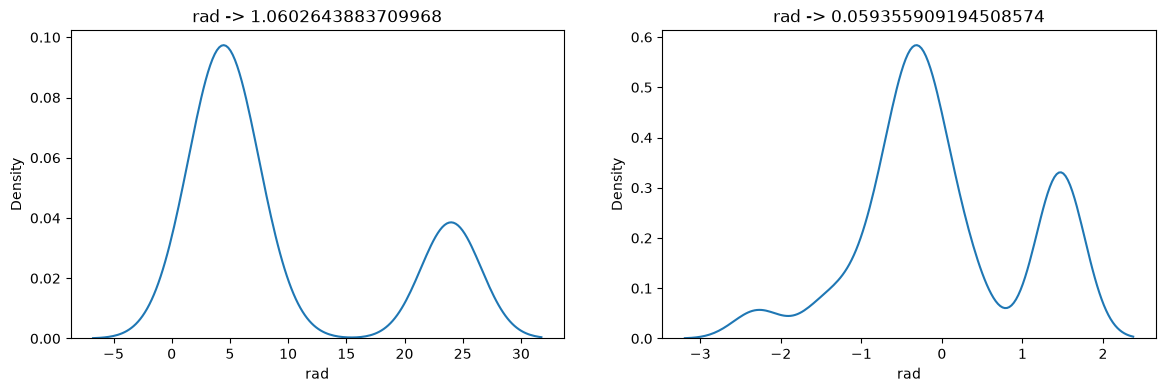

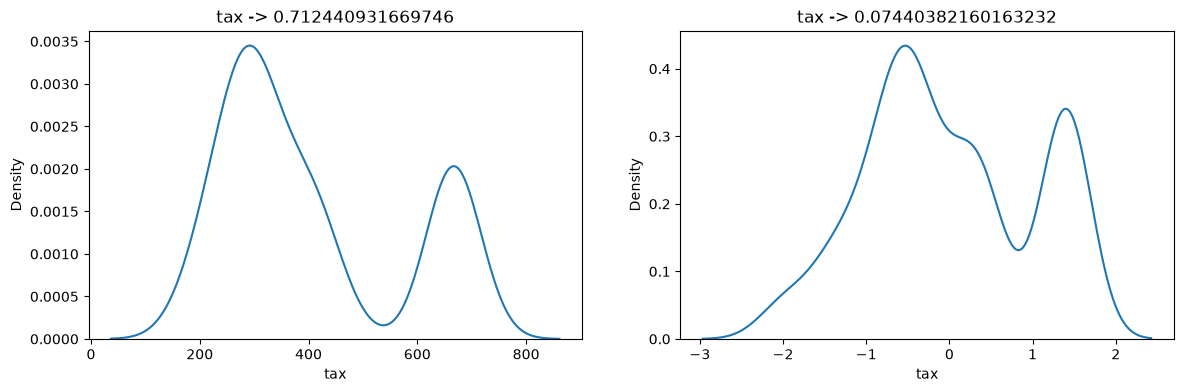

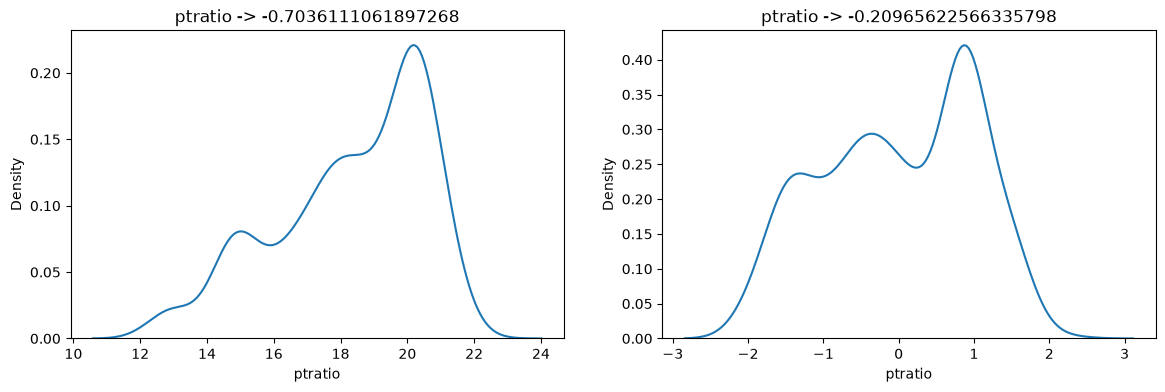

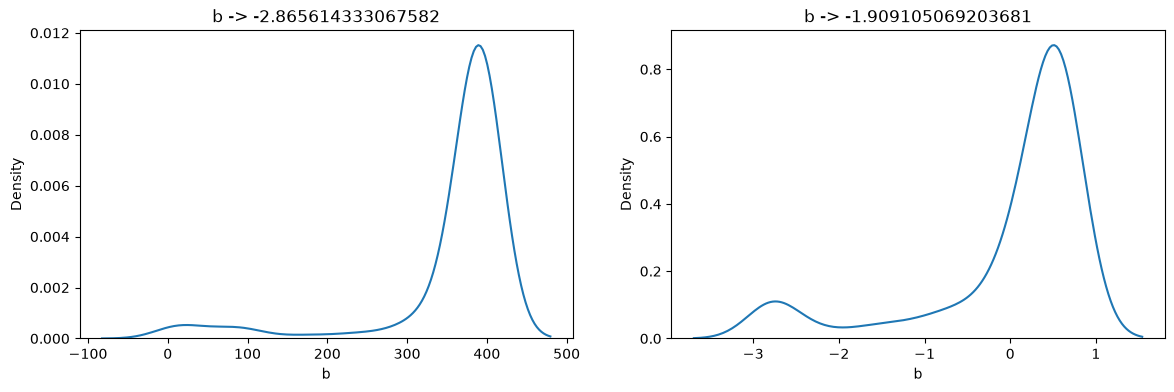

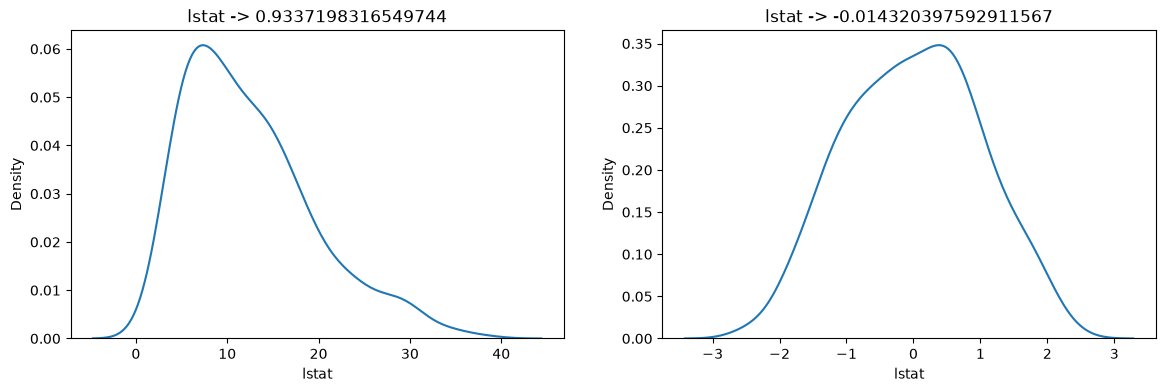

In [8]:
# Before and after comparision for Box-Cox Plot
X_train_transformed2 = pd.DataFrame(X_train_transformed2 ,columns=X_train.columns)

for col in X_train_transformed2.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.kdeplot(X_train[col])
    txt = col + " -> " + str(X_train[col].skew())
    plt.title(txt)

    plt.subplot(122)
    sns.kdeplot(X_train_transformed2[col])
    txt1 = col + " -> " + str(X_train_transformed2[col].skew())
    plt.title(txt1)

    plt.show()

## Applying Box Cox

In [9]:
pt = PowerTransformer(method='box-cox')

X_train_transformed = pt.fit_transform(X_train+0.000001)
X_test_transformed = pt.transform(X_test+0.000001)

pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_})

,cols,box_cox_lambdas
0,crim,-0.114374
1,zn,-0.181510
2,indus,0.389192
3,chas,-1.008349
4,nox,-0.938023
5,rm,0.147907
6,age,1.362922
7,dis,-0.165778
8,rad,-0.134975
9,tax,-0.526450


# Comparing Box cox lambdas with Yeo Johnson

In [10]:
# Side by side Lambdas
pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_,'Yeo_Johnson_lambdas':pt1.lambdas_})

,cols,box_cox_lambdas,Yeo_Johnson_lambdas
0,crim,-0.114374,-0.958995
1,zn,-0.181510,-0.867045
2,indus,0.389192,0.332416
3,chas,-1.008349,-20.097985
4,nox,-0.938023,-4.033137
5,rm,0.147907,-0.014434
6,age,1.362922,1.388267
7,dis,-0.165778,-0.459648
8,rad,-0.134975,-0.367935
9,tax,-0.526450,-0.530211
